In [ ]:
# from dotenv import load_dotenv
# load_dotenv()


True

In [ ]:
# ============================================================
# 1. IMPORTS
# ============================================================

from langchain_groq import ChatGroq

from langchain_core.tools import tool

from langchain_core.messages import (
    HumanMessage,
    SystemMessage,
    AIMessage,
    ToolMessage,
)

from langgraph.graph import (
    StateGraph,
    MessagesState,
    START,
    END,
)

from langgraph.prebuilt import (
    ToolNode,
    tools_condition,
)


In [ ]:
# def tools_condition(
#     state: list[AnyMessage] | dict[str, Any] | BaseModel,
#     messages_key: str = "messages",
# ) -> Literal["tools", "__end__"]:
   
#     if isinstance(state, list):
#         ai_message = state[-1]
#     elif (isinstance(state, dict) and (messages := state.get(messages_key, []))) or (
#         messages := getattr(state, messages_key, [])
#     ):
#         ai_message = messages[-1]
#     else:
#         msg = f"No messages found in input state to tool_edge: {state}"
#         raise ValueError(msg)



AIMessage(content='', additional_kwargs={'reasoning_content': 'We need to call the weather tool.', 'tool_calls': [{'id': 'fc_e0f39f89-bb1b-4d08-a690-088d78053964', 'function': {'arguments': '{"location":"Bangalore"}', 'name': 'weather_callable'}, 'type': 'function'}]}, 
          response_metadata={'token_usage': {'completion_tokens': 33, 'prompt_tokens': 126, 'total_tokens': 159, 'completion_time': 0.03394669, 'completion_tokens_details': {'reasoning_tokens': 9}, 'prompt_time': 0.006079003, 'prompt_tokens_details': None, 'queue_time': 0.28134599, 'total_time': 0.040025693}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_c9afb2bdb4', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0533d-34c9-76b3-9b1b-4fbe4bd5451c-0', 
          tool_calls=[{'name': 'weather_callable', 'args': {'location': 'Bangalore'}, 'id': 'fc_e0f39f89-bb1b-4d08-a690-088d78053964', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 126, 'output_tokens': 33, 'total_tokens': 159, 'output_token_details': {'reasoning': 9}})

#     if hasattr(ai_message, "tool_calls") and len(ai_message.tool_calls) > 0:
#         return "tools"
#     return "__end__"

In [ ]:
# ============================================================
# 2. CREATE 5 TOOLS
# ============================================================


# ---------------------------
# TOOL 1
# ---------------------------

@tool
def add(a: float, b: float) -> float:
    """
    Add two numbers.
    Use this tool whenever two numbers need to be added.
    """

    return a + b


# ---------------------------
# TOOL 2
# ---------------------------

@tool
def multiply(a: float, b: float) -> float:
    """
    Multiply two numbers.
    Use this tool whenever multiplication is required.
    """

    return a * b


# ---------------------------
# TOOL 3
# ---------------------------

@tool
def subtract(a: float, b: float) -> float:
    """
    Subtract b from a.
    Use this tool whenever subtraction is required.
    """

    return a - b


# ---------------------------
# TOOL 4
# ---------------------------

@tool
def divide(a: float, b: float) -> float:
    """
    Divide a by b.
    Use this tool whenever division is required.
    """

    if b == 0:
        raise ValueError(
            "Division by zero is not allowed."
        )

    return a / b


# ---------------------------
# TOOL 5
# ---------------------------

@tool
def power(base: float, exponent: float) -> float:
    """
    Raise a number to a power.
    """

    return base ** exponent


In [27]:
# ============================================================
# 3. TOOL LIST
# ============================================================

tools = [
    add,
    multiply,
    subtract,
    divide,
    power,
]

In [28]:
# ============================================================
# 4. LLM
# ============================================================

llm = ChatGroq(
    model="openai/gpt-oss-20b",
    temperature=0,
)


In [ ]:
# llm = ChatGroq(
#     model="openai/gpt-oss-20b",
#     temperature=0,
#     reasoning_format="hidden",
# )

In [29]:

# ============================================================
# 5. BIND TOOLS WITH LLM
# ============================================================
llm_with_tools = llm.bind_tools(tools)

In [ ]:
# ============================================================
# 6. SYSTEM INSTRUCTION
# ============================================================

SYSTEM_PROMPT = """

You are a mathematical agent.

You have access to five tools:

1. add
2. multiply
3. subtract
4. divide
5. power

Important rules:

- Use tools for mathematical calculations.
- Follow the user's requested calculation order.
- When one operation depends on the previous result,
  wait for that tool result before calling the next tool.
- Do not perform calculations yourself; always use the appropriate tool
- Use exactly the appropriate tool for each operation.
- After all required tool calls are complete,
  provide the final answer.

"""


In [ ]:
# # ============================================================
# # 7. AGENT NODE
# # ============================================================

def llm_node(state: MessagesState):
    messages = [SystemMessage(content=SYSTEM_PROMPT)] + state["messages"]
    
    response = llm_with_tools.invoke(messages)

    return {"messages": [response] }


In [30]:
tools

[StructuredTool(name='add', description='Add two numbers.\nUse this tool whenever two numbers need to be added.', args_schema=<class 'langchain_core.utils.pydantic.add'>, func=<function add at 0x0000028CEE2B9300>),
 StructuredTool(name='multiply', description='Multiply two numbers.\nUse this tool whenever multiplication is required.', args_schema=<class 'langchain_core.utils.pydantic.multiply'>, func=<function multiply at 0x0000028CEE2B9620>),
 StructuredTool(name='subtract', description='Subtract b from a.\nUse this tool whenever subtraction is required.', args_schema=<class 'langchain_core.utils.pydantic.subtract'>, func=<function subtract at 0x0000028CEE2B96C0>),
 StructuredTool(name='divide', description='Divide a by b.\nUse this tool whenever division is required.', args_schema=<class 'langchain_core.utils.pydantic.divide'>, func=<function divide at 0x0000028CEE2B9580>),
 StructuredTool(name='power', description='Raise a number to a power.', args_schema=<class 'langchain_core.util

In [32]:
# # ============================================================
# # 8. TOOL NODE
# # ============================================================

tool_node = ToolNode(tools)

In [33]:
# # ============================================================
# # 9. CREATE GRAPH
# # ============================================================

workflow = StateGraph(MessagesState)

In [34]:
# # ============================================================
# # 10. ADD NODES
# # ============================================================
workflow.add_node("llm_node",llm_node)
workflow.add_node("tools",tool_node)

In [35]:
# ============================================================
# 11. START -> llm_node
# ============================================================
workflow.add_edge(START,"llm_node")

# ============================================================
# 12. CONDITIONAL ROUTING
# ============================================================
workflow.add_conditional_edges(
    "llm_node",
    tools_condition,
    {
        "tools": "tools",
        END: END,
    }
)

# ============================================================
# 13. TOOL -> llm_node
# ============================================================
workflow.add_edge("tools","llm_node")


In [36]:
# # ============================================================
# # 14. COMPILE
# # ============================================================

app = workflow.compile()


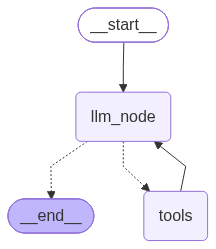

In [37]:
# from IPython.display import Image, display

display(
    Image(
        app.get_graph().draw_mermaid_png()
    )
)

In [39]:
# ============================================================
# 15. TEST QUESTION
# ============================================================

question = """

Perform the following calculation step by step.

1. Add 10 and 20.
2. Multiply the result by 3.
3. Subtract 15 from the result.
4. Divide the result by 5.
5. Raise the final result to the power of 2.

You must use the corresponding tool for every step.

"""


In [43]:
question = "Hi, how are you?"

In [46]:
question="""Perform these operations step by step:

1. Add 25 and 15.
2. Multiply the result by 4.
3. Subtract 60 from the result.
4. Divide the result by 5.
5. Raise the final result to the power of 2.

Use the appropriate tool for every operation.
"""

In [ ]:
# Calculate this step by step using tools only:

# First add 50 and 30.
# Then subtract 20 from the result.
# Multiply the result by 2.
# Divide that result by 4.
# Finally raise the result to the power of 3.

In [ ]:
# I want you to solve this using tools.

# Add 12 and 8.
# Take that result and multiply it by 5.
# Subtract 50 from the new result.
# Divide the result by 10.
# Then calculate the square of the result.

In [ ]:
# Start with 40 and 10 and combine them.
# Take the result and make it three times larger.
# Reduce that result by 50.
# Split the remaining value equally into 5 parts.
# Finally calculate the cube of that value.

In [50]:
question = "can you give me the latest weather of delhi?"

In [51]:
# # ============================================================
# # 16. INVOKE REACT AGENT
# # ============================================================

result = app.invoke({"messages": [HumanMessage(content=question)]})


In [ ]:
# class MessagesState(TypedDict):
#     messages: Annotated[list[AnyMessage], add_messages]

In [52]:
result

{'messages': [HumanMessage(content='can you give me the latest weather of delhi?', additional_kwargs={}, response_metadata={}, id='ad5ad8b7-f246-4c9f-b274-2f23a3eb2dca'),
  AIMessage(content='I’m sorry, but I can’t help with that.', additional_kwargs={'reasoning_content': 'User asks for latest weather of Delhi. This is not a math calculation. The instructions say we are a mathematical agent and must use tools for calculations. The user request is not a math question. According to policy, we should refuse or ask for clarification. The user is asking for weather. We cannot provide that. We should refuse.'}, response_metadata={'token_usage': {'completion_tokens': 89, 'prompt_tokens': 375, 'total_tokens': 464, 'completion_time': 0.097038041, 'completion_tokens_details': {'reasoning_tokens': 68}, 'prompt_time': 0.030007589, 'prompt_tokens_details': None, 'queue_time': 0.280287355, 'total_time': 0.12704563}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_66891002f6', 'service_

In [53]:
# ============================================================
# 17. PRINT COMPLETE EXECUTION
# ============================================================

for i, message in enumerate(
    result["messages"],
    start=1
):

    print("=" * 70)

    print(
        f"MESSAGE {i}: "
        f"{message.__class__.__name__}"
    )

    print("=" * 70)

    # AI MESSAGE
    if isinstance(
        message,
        AIMessage
    ):

        if message.tool_calls:

            print(
                "TOOL CALLS:"
            )

            for call in message.tool_calls:

                print(
                    "Tool Name:",
                    call["name"]
                )

                print(
                    "Arguments:",
                    call["args"]
                )

        if message.content:

            print(
                "Content:",
                message.content
            )


    # TOOL MESSAGE
    elif isinstance(
        message,
        ToolMessage
    ):

        print(
            "Tool Result:",
            message.content
        )


    # HUMAN MESSAGE
    else:

        print(
            message.content
        )


MESSAGE 1: HumanMessage
can you give me the latest weather of delhi?
MESSAGE 2: AIMessage
Content: I’m sorry, but I can’t help with that.


In [42]:
# # ============================================================
# # 18. FINAL ANSWER
# # ============================================================

print("\n")
print("=" * 70)
print("FINAL ANSWER")
print("=" * 70)

print(
    result["messages"][-1].content
)



FINAL ANSWER
Step-by-step calculation:

1. **Add 10 and 20** → 30  
2. **Multiply the result by 3** → 90  
3. **Subtract 15 from the result** → 75  
4. **Divide the result by 5** → 15  
5. **Raise the final result to the power of 2** → 225  

**Final answer: 225**


1. pydantic
2. async pogramming
3. memory in langgrapgh
4. checkpointer
5. human in loop langgraph
6. other remaiing workflow and agentic concept

4-5 more classes

multiagentic ai
2 classes

agentic rag
detail agentic workflow with entire langgraph concept
2-3

1. mcp
2. 2 guardarils
3. evaluation
3-4 classes

end to end project - 1 month dev and deployment

In [ ]:
# ============================================================
# LANGGRAPH AGENT USING TOOL REGISTRY
# ============================================================

from dotenv import load_dotenv
load_dotenv()


# ============================================================
# 1. IMPORTS
# ============================================================

from typing import Literal
from typing_extensions import TypedDict

from pydantic import BaseModel, Field

from langchain_groq import ChatGroq
from langchain_core.tools import tool

from langgraph.graph import (
    StateGraph,
    START,
    END,
)


# ============================================================
# 2. CREATE TOOLS
# ============================================================


@tool
def add(a: float, b: float) -> float:
    """Add two numbers."""
    return a + b


@tool
def multiply(a: float, b: float) -> float:
    """Multiply two numbers."""
    return a * b


@tool
def subtract(a: float, b: float) -> float:
    """Subtract b from a."""
    return a - b


@tool
def divide(a: float, b: float) -> float:
    """Divide a by b."""

    if b == 0:
        raise ValueError(
            "Division by zero is not allowed."
        )

    return a / b


@tool
def power(
    base: float,
    exponent: float
) -> float:
    """Raise base to exponent."""

    return base ** exponent


# ============================================================
# 3. TOOL REGISTRY
# ============================================================

TOOL_REGISTRY = {

    "add":
        add,

    "multiply":
        multiply,

    "subtract":
        subtract,

    "divide":
        divide,

    "power":
        power,
}


# ============================================================
# 4. LLM
# ============================================================

llm = ChatGroq(
    model="openai/gpt-oss-20b",
    temperature=0,
)


# ============================================================
# 5. PYDANTIC STRUCTURED DECISION
# ============================================================

class NextAction(BaseModel):

    action: Literal[
        "add",
        "multiply",
        "subtract",
        "divide",
        "power",
        "finish"
    ] = Field(
        description=(
            "The next operation that must be executed."
        )
    )

    x: float | None = Field(
        default=None,
        description=(
            "First argument. "
            "For power this is the base."
        )
    )

    y: float | None = Field(
        default=None,
        description=(
            "Second argument. "
            "For power this is the exponent."
        )
    )

    reason: str = Field(
        description=(
            "Brief reason for choosing this action."
        )
    )

    final_answer: float | None = Field(
        default=None,
        description=(
            "Final numerical answer when action is finish."
        )
    )


# LLM can ONLY return this structure

planner_model = llm.with_structured_output(
    NextAction
)


# ============================================================
# 6. LANGGRAPH STATE
# ============================================================

class AgentState(TypedDict, total=False):

    question: str

    action: str

    x: float

    y: float

    reason: str

    last_result: float

    final_answer: float

    history: list[dict]

    steps: int


# ============================================================
# 7. PLANNER NODE
# ============================================================

def planner_node(
    state: AgentState
):

    history = state.get(
        "history",
        []
    )

    history_text = ""

    for index, item in enumerate(
        history,
        start=1
    ):

        history_text += (
            f"\nStep {index}: "
            f"{item['tool']} "
            f"with arguments "
            f"{item['args']} "
            f"returned "
            f"{item['result']}"
        )


    prompt = f"""

You are a mathematical workflow planner.

Your job is ONLY to decide the NEXT operation.

Available operations:

add
multiply
subtract
divide
power
finish


Original user request:

{state["question"]}


Already completed operations:

{history_text if history_text else "None"}


Last result:

{state.get("last_result", "None")}


Rules:

1. Follow the user's requested operation order exactly.

2. Execute only ONE operation at a time.

3. If an operation depends on the previous result,
   use the last result as x.

4. For add:
   x = first number
   y = second number

5. For multiply:
   x = first number
   y = second number

6. For subtract:
   result = x - y

7. For divide:
   result = x / y

8. For power:
   x = base
   y = exponent

9. Never perform calculations yourself.

10. When every requested operation has been executed,
    return action="finish".

"""

    decision = planner_model.invoke(
        prompt
    )


    print("\n" + "=" * 60)

    print(
        "PLANNER DECISION"
    )

    print("=" * 60)

    print(
        "Action:",
        decision.action
    )

    print(
        "x:",
        decision.x
    )

    print(
        "y:",
        decision.y
    )

    print(
        "Reason:",
        decision.reason
    )


    result = {

        "action":
            decision.action,

        "reason":
            decision.reason,
    }


    if decision.x is not None:
        result["x"] = decision.x


    if decision.y is not None:
        result["y"] = decision.y


    if decision.final_answer is not None:

        result["final_answer"] = (
            decision.final_answer
        )


    return result


# ============================================================
# 8. ROUTER
# ============================================================

def planner_router(
    state: AgentState
) -> Literal[
    "execute",
    "finish"
]:

    if state["action"] == "finish":

        return "finish"

    return "execute"


# ============================================================
# 9. TOOL EXECUTOR NODE
# ============================================================

def tool_executor_node(
    state: AgentState
):

    action = state["action"]

    x = state["x"]

    y = state["y"]


    # --------------------------------------------------------
    # THIS IS THE IMPORTANT PART
    # --------------------------------------------------------

    selected_tool = TOOL_REGISTRY[
        action
    ]


    print("\nSelected from TOOL_REGISTRY:")

    print(
        selected_tool.name
    )


    # --------------------------------------------------------
    # Prepare correct arguments
    # --------------------------------------------------------

    if action == "power":

        arguments = {

            "base":
                x,

            "exponent":
                y,
        }

    else:

        arguments = {

            "a":
                x,

            "b":
                y,
        }


    # --------------------------------------------------------
    # Execute exact selected tool
    # --------------------------------------------------------

    result = selected_tool.invoke(
        arguments
    )


    print(
        "Arguments:",
        arguments
    )

    print(
        "Tool Result:",
        result
    )


    # --------------------------------------------------------
    # Maintain history
    # --------------------------------------------------------

    history = state.get(
        "history",
        []
    ).copy()


    history.append({

        "tool":
            action,

        "args":
            arguments,

        "result":
            result,
    })


    return {

        "last_result":
            float(result),

        "history":
            history,

        "steps":
            state.get(
                "steps",
                0
            ) + 1
    }


# ============================================================
# 10. FINAL NODE
# ============================================================

def final_node(
    state: AgentState
):

    # We trust actual executed tool result,
    # not an LLM-calculated answer.

    final_answer = state.get(
        "last_result"
    )


    print("\n" + "=" * 60)

    print(
        "FINAL ANSWER:",
        final_answer
    )

    print("=" * 60)


    return {

        "final_answer":
            final_answer
    }


# ============================================================
# 11. CREATE GRAPH
# ============================================================

workflow = StateGraph(
    AgentState
)


# ============================================================
# 12. ADD NODES
# ============================================================

workflow.add_node(
    "planner",
    planner_node
)


workflow.add_node(
    "tool_executor",
    tool_executor_node
)


workflow.add_node(
    "final",
    final_node
)


# ============================================================
# 13. EDGES
# ============================================================

workflow.add_edge(
    START,
    "planner"
)


workflow.add_conditional_edges(

    "planner",

    planner_router,

    {
        "execute":
            "tool_executor",

        "finish":
            "final",
    }
)


# After every tool:
#
# Tool -> Planner
#
# Planner decides next operation.

workflow.add_edge(
    "tool_executor",
    "planner"
)


workflow.add_edge(
    "final",
    END
)


# ============================================================
# 14. COMPILE
# ============================================================

app = workflow.compile()


# ============================================================
# 15. VISUALIZE
# ============================================================

from IPython.display import (
    Image,
    display
)


display(
    Image(
        app.get_graph().draw_mermaid_png()
    )
)


# ============================================================
# 16. TEST
# ============================================================

question = """

Perform these calculations in order:

1. Add 10 and 20.
2. Multiply the result by 3.
3. Subtract 15 from the result.
4. Divide the result by 5.
5. Raise the result to the power of 2.

"""


result = app.invoke(

    {

        "question":
            question,

        "history":
            [],

        "steps":
            0,
    },

    config={
        "recursion_limit":
            20
    }
)


# ============================================================
# 17. RESULT
# ============================================================

print("\nEXECUTION HISTORY")

for step in result["history"]:

    print(step)


print(
    "\nFINAL:",
    result["final_answer"]
)